# Quantum Computing Basics with a Portfolio Search Example

## What students will learn
- How a qubit is different from a classical bit.
- How superposition changes the possible outcomes of a computation.
- How a very small quantum circuit can represent 4 candidate portfolios.

## What we will build
- A classical finance workflow to compare 4 toy portfolios.
- A 2-qubit Grover-style circuit that marks one portfolio and amplifies it.

## Why the example is financial
- In finance, we often compare several candidate portfolios.
- That makes portfolio choice a good toy example for search ideas.

## Warning
"This is an educational toy example, not investment advice and not a real quantum advantage claim."

## Learning objectives
1. Understand what a qubit is.
2. Understand superposition.
3. Understand measurement probabilities.
4. Understand basic quantum gates: X, H, Z/CZ.
5. Understand a simple oracle.
6. Understand the intuition of Grover amplification.
7. Apply these ideas to a toy portfolio-selection problem.


## 1. Big picture

We will combine a classical finance part with a small quantum computing part.

```text
Classical finance part:
prices -> returns -> portfolio metrics -> best portfolio

Quantum computing part:
candidate portfolios -> quantum states -> oracle -> amplification -> measurement
```

Important idea:
- The quantum circuit does not compute the financial metrics.
- The financial metrics are computed classically.
- The quantum part shows how a marked solution can be amplified.


In [ ]:
# We install the main libraries used in this notebook.
# In Google Colab, this step prepares the environment.
!pip install qiskit yfinance --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


def plot_probabilities(prob_dict, title):
    # Sort the labels so the chart is easy to read.
    states = sorted(prob_dict.keys())
    probs = [prob_dict[state] for state in states]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(states, probs, color="#4C78A8", edgecolor="black")
    plt.ylim(0, 1)
    plt.xlabel("Basis state")
    plt.ylabel("Probability")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)

    # Add the values above the bars.
    for bar, prob in zip(bars, probs):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            prob + 0.02,
            f"{prob:.2f}",
            ha="center",
            va="bottom"
        )

    plt.show()


## 2. Part A: One qubit intuition

A classical bit is either `0` or `1`.

A qubit can be in a combination of `|0>` and `|1>`.

In this notebook, we use a very simple analogy:
- `|0>` = "safe"
- `|1>` = "risky"

When we measure a qubit, we do not directly see the full combination.
We see an outcome with some probability.


Statevector: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Probabilities: {np.str_('0'): np.float64(1.0)}


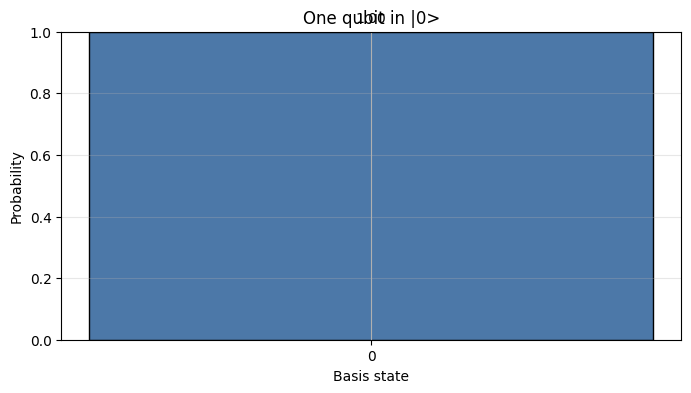

In [ ]:
qc = QuantumCircuit(1)
state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print("Statevector:", state)
print("Probabilities:", probs)
plot_probabilities(probs, "One qubit in |0>")


   ┌───┐
q: ┤ X ├
   └───┘
Statevector: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
Probabilities: {np.str_('1'): np.float64(1.0)}


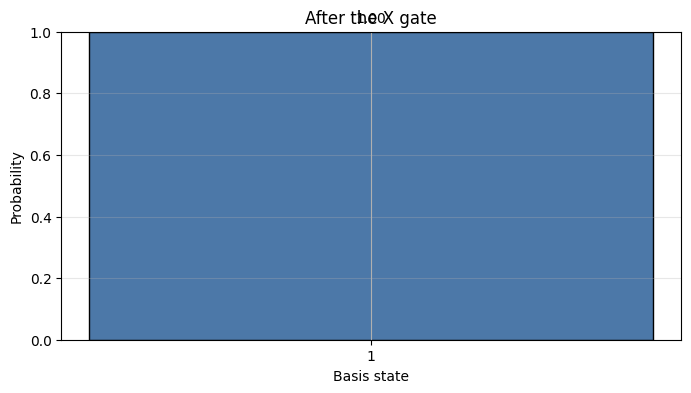

In [ ]:
# X flips |0> to |1>.
qc = QuantumCircuit(1)
qc.x(0)

print(qc.draw())

state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print("Statevector:", state)
print("Probabilities:", probs)
plot_probabilities(probs, "After the X gate")


{np.str_('0'): np.float64(1.0)}


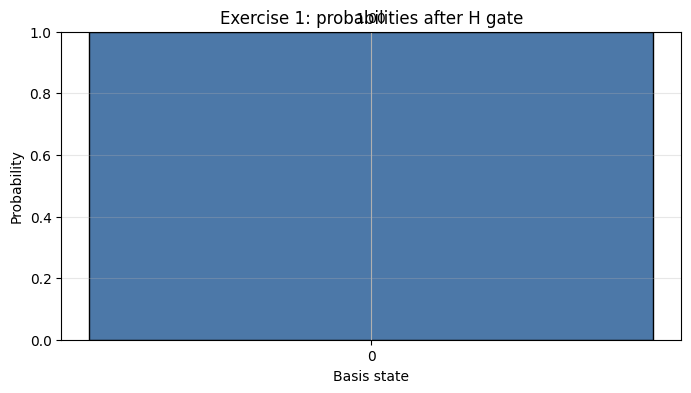

In [ ]:
qc = QuantumCircuit(1)

# // TODO: Apply a Hadamard gate to qubit 0

qc.h(0)

state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print(probs)
plot_probabilities(probs, "Probabilities after H gate")


## 3. Explanation: What did the H gate do?

The Hadamard gate, written as `H`, creates superposition.

For one qubit, that means the measurement outcomes become:
- about 50% `|0>`
- about 50% `|1>`

This is not exactly the same as a classical random coin before measurement.

For this beginner notebook, we focus on the output probabilities.


## 4. Part B: Financial data for a toy portfolio problem

We will use 4 ETFs:
- `SPY`: broad US equity
- `QQQ`: technology-heavy equity
- `TLT`: long-term bonds
- `GLD`: gold

We will create 4 candidate portfolios by hand.

Each quantum basis state will represent one candidate portfolio.

Important note:
This is educational. The portfolios are not recommendations.


Downloaded price table shape: (2104, 4)


Ticker,SPY,QQQ,TLT,GLD
Date,,,,
2018-01-02,236.562164,150.222153,99.093880,125.150002
2018-01-03,238.058502,151.681808,99.567711,124.820000
2018-01-04,239.061813,151.947220,99.551926,125.459999
2018-01-05,240.654938,153.473267,99.267632,125.330002
2018-01-08,241.095001,154.070312,99.204491,125.309998


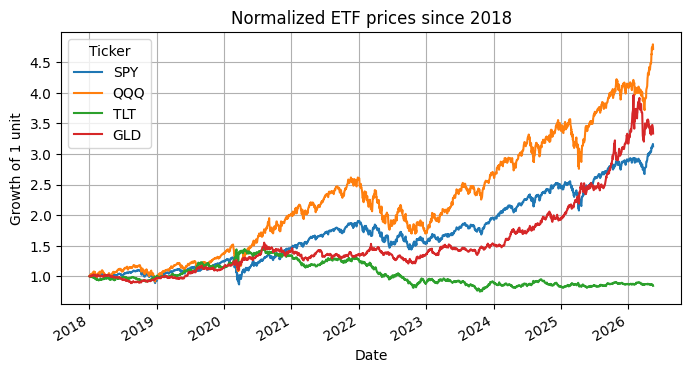

In [ ]:
tickers = ["SPY", "QQQ", "TLT", "GLD"]

# We download daily historical data from Yahoo Finance.
raw_data = yf.download(
    tickers=tickers,
    start="2018-01-01",
    auto_adjust=False,
    progress=False,
    threads=False
)

# yfinance may return a MultiIndex table for several tickers.
# We keep only adjusted close prices if they exist.
if isinstance(raw_data.columns, pd.MultiIndex):
    first_level = raw_data.columns.get_level_values(0)

    if "Adj Close" in first_level:
        prices = raw_data["Adj Close"].copy()
    elif "Close" in first_level:
        print("Adjusted close not found. Using Close instead.")
        prices = raw_data["Close"].copy()
    else:
        raise ValueError("Could not find adjusted close prices in the downloaded data.")
else:
    if "Adj Close" in raw_data.columns:
        prices = raw_data[["Adj Close"]].copy()
        prices.columns = tickers[:1]
    elif "Close" in raw_data.columns:
        print("Adjusted close not found. Using Close instead.")
        prices = raw_data[["Close"]].copy()
        prices.columns = tickers[:1]
    else:
        raise ValueError("Could not find adjusted close prices in the downloaded data.")

# Remove rows with missing values.
prices = prices.dropna().copy()

# Check that all expected tickers are present.
missing_tickers = [ticker for ticker in tickers if ticker not in prices.columns]
if missing_tickers:
    raise ValueError(f"Missing price data for: {missing_tickers}")

# Reorder the columns to match our chosen ticker order.
prices = prices[tickers]

print("Downloaded price table shape:", prices.shape)
display(prices.head())

# A small visual helps compare the assets over time.
normalized_prices = prices / prices.iloc[0]
normalized_prices.plot(title="Normalized ETF prices since 2018")
plt.ylabel("Growth of 1 unit")
plt.show()


In [ ]:
# Daily percentage returns.
returns = prices.pct_change().dropna()

# Annualized mean return.
# We multiply by 252 because there are about 252 trading days in a year.
mu = returns.mean() * 252

# Annualized covariance matrix.
cov = returns.cov() * 252

print("Annualized mean returns")
display(mu.to_frame(name="annual_return"))

print("Annualized covariance matrix")
display(cov)


Annualized mean returns


,annual_return
Ticker,
SPY,0.155120
QQQ,0.214433
TLT,-0.008235
GLD,0.158206


Annualized covariance matrix


Ticker,SPY,QQQ,TLT,GLD
Ticker,,,,
SPY,0.037031,0.043006,-0.004234,0.003361
QQQ,0.043006,0.056785,-0.003461,0.004545
TLT,-0.004234,-0.003461,0.024131,0.005925
GLD,0.003361,0.004545,0.005925,0.027612


## 5. Define four candidate portfolios

Each portfolio is a vector of weights over the 4 ETFs.

We use this mapping:
- `"00"` = Conservative
- `"01"` = Balanced
- `"10"` = Growth
- `"11"` = Aggressive

Example weights:
- Conservative: SPY 20%, QQQ 0%, TLT 60%, GLD 20%
- Balanced: SPY 40%, QQQ 20%, TLT 30%, GLD 10%
- Growth: SPY 50%, QQQ 30%, TLT 10%, GLD 10%
- Aggressive: SPY 60%, QQQ 35%, TLT 0%, GLD 5%

Each set of weights must sum to 1.


In [ ]:
portfolios = {
    "00": {"name": "Conservative", "weights": np.array([0.20, 0.00, 0.60, 0.20])},
    "01": {"name": "Balanced", "weights": np.array([0.40, 0.20, 0.30, 0.10])},
    "10": {"name": "Growth", "weights": np.array([0.50, 0.30, 0.10, 0.10])},
    "11": {"name": "Aggressive", "weights": np.array([0.60, 0.35, 0.00, 0.05])},
}

rows = []
for bitstring, info in portfolios.items():
    row = {
        "bitstring": bitstring,
        "name": info["name"],
        "SPY": info["weights"][0],
        "QQQ": info["weights"][1],
        "TLT": info["weights"][2],
        "GLD": info["weights"][3],
        "weight_sum": info["weights"].sum(),
    }
    rows.append(row)

portfolio_table = pd.DataFrame(rows)
display(portfolio_table)


,bitstring,name,SPY,QQQ,TLT,GLD,weight_sum
0,00,Conservative,0.2,0.00,0.6,0.20,1.0
1,01,Balanced,0.4,0.20,0.3,0.10,1.0
2,10,Growth,0.5,0.30,0.1,0.10,1.0
3,11,Aggressive,0.6,0.35,0.0,0.05,1.0


In [ ]:
# // TODO: Change the Balanced portfolio weights.
# The weights must still sum to 1.
portfolios["01"]["weights"] = np.array([0.40, 0.15, 0.30, 0.15])

# // TODO: Check that the weights sum to 1.
print("Sum of weights:", portfolios["01"]["weights"].sum())

Sum of weights: 1.0


## 6. Compute portfolio return, volatility and Sharpe ratio

We will use three basic portfolio metrics:
- Portfolio return: the weighted average of expected asset returns.
- Portfolio volatility: the risk level from the covariance matrix.
- Sharpe ratio: return per unit of risk.

We will use an annual risk-free rate of `rf = 0.02`.


In [ ]:
def portfolio_return(weights, mu):
    # Expected portfolio return is a weighted average.
    return float(np.dot(weights, mu))


def portfolio_volatility(weights, cov):
    # Portfolio variance uses the covariance matrix.
    variance = float(weights.T @ cov.values @ weights)
    return float(np.sqrt(variance))


def portfolio_sharpe(weights, mu, cov, rf=0.02):
    # Sharpe ratio compares excess return to risk.
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return (ret - rf) / vol


,bitstring,name,annual_return,annual_volatility,sharpe
0,10,Growth,0.1569,0.1670,0.8198
1,11,Aggressive,0.1760,0.1969,0.7924
2,01,Balanced,0.1155,0.1224,0.7803
3,00,Conservative,0.0577,0.1093,0.3451


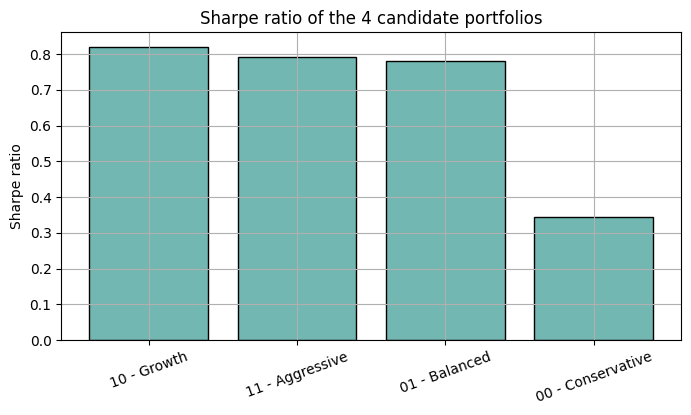

The best portfolio according to Sharpe is: 10 (Growth)


In [ ]:
metric_rows = []

for bitstring, info in portfolios.items():
    weights = info["weights"]

    metric_rows.append(
        {
            "bitstring": bitstring,
            "name": info["name"],
            "annual_return": portfolio_return(weights, mu),
            "annual_volatility": portfolio_volatility(weights, cov),
            "sharpe": portfolio_sharpe(weights, mu, cov, rf=0.02),
        }
    )

metrics_df = pd.DataFrame(metric_rows)
metrics_df = metrics_df.sort_values("sharpe", ascending=False).reset_index(drop=True)

display(metrics_df.round(4))

plt.figure(figsize=(8, 4))
plt.bar(metrics_df["bitstring"] + " - " + metrics_df["name"], metrics_df["sharpe"], color="#72B7B2", edgecolor="black")
plt.ylabel("Sharpe ratio")
plt.title("Sharpe ratio of the 4 candidate portfolios")
plt.xticks(rotation=20)
plt.show()

best_bitstring = metrics_df.loc[0, "bitstring"]
best_name = metrics_df.loc[0, "name"]

print(f"The best portfolio according to Sharpe is: {best_bitstring} ({best_name})")


In [ ]:
# // TODO: Instead of max Sharpe, select the portfolio with minimum volatility.
# Store the answer in best_minvol_bitstring.

best_minvol_bitstring = metrics_df.loc[
    metrics_df["annual_volatility"].idxmin(), "bitstring"
]
# // TODO: Print the selected portfolio.
print("Best portfolio under the minimum-volatility rule:", best_minvol_bitstring)


Best portfolio under the minimum-volatility rule: 00


## 7. Part C: Two qubits represent four portfolios

With 2 qubits, we have 4 basis states:
- `|00>`
- `|01>`
- `|10>`
- `|11>`

These are exactly our 4 candidate portfolios.

If we apply `H` to both qubits, we create an equal superposition over all 4 portfolios.


Probabilities: {np.str_('00'): np.float64(0.2499999999999999), np.str_('01'): np.float64(0.2499999999999999), np.str_('10'): np.float64(0.2499999999999999), np.str_('11'): np.float64(0.2499999999999999)}


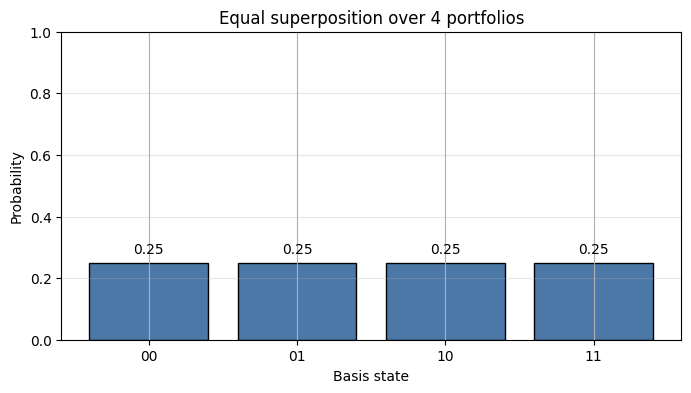

Could not draw the circuit with matplotlib.
Reason: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."
     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     └───┘


In [ ]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)

state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print("Probabilities:", probs)
plot_probabilities(probs, "Equal superposition over 4 portfolios")

# All 4 basis states should have probability 25%.
try:
    display(qc.draw("mpl"))
except Exception as error:
    print("Could not draw the circuit with matplotlib.")
    print("Reason:", error)
    print(qc.draw())


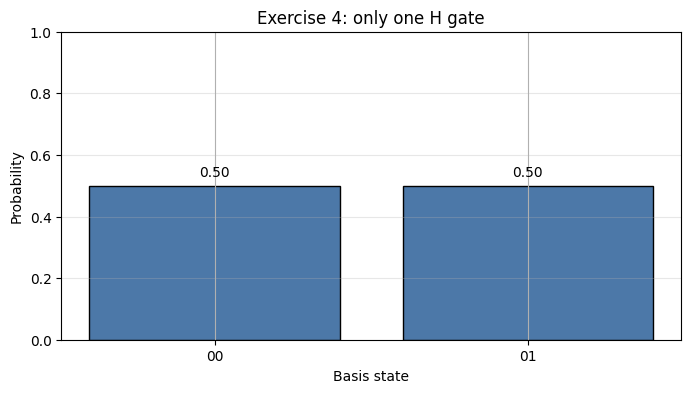

In [ ]:
# // TODO: Apply H only to qubit 0, not qubit 1.
qc = QuantumCircuit(2)
qc.h(0)

state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()
plot_probabilities(probs, "Exercise 4: only one H gate")

# Question:
# Which states appear? -- we can see 00 state and 01 state
# Why? -- this is because we applied H to only qubit 0 and not to the other. so qubit 1 stayed fixed inside |0>


## 8. Part D: Oracle intuition

An oracle is a circuit that marks the correct solution.

In Grover's idea, marking means flipping the phase of the target state.

Important:
- The probabilities do not change immediately after the oracle.
- The phase changes.
- The diffuser then turns this phase information into higher probability.


In [ ]:
def apply_phase_oracle(qc, target_bitstring):
    # The target must be a 2-bit label such as "00", "01", "10", or "11".
    if len(target_bitstring) != 2 or any(bit not in "01" for bit in target_bitstring):
        raise ValueError("target_bitstring must be a 2-character string like '00' or '11'.")

    # In this educational notebook we use bitstrings as labels.
    # Qiskit prints state labels as q1 q0, so we reverse the string
    # when we map label bits to qubit indices.
    for qubit_index, bit in enumerate(reversed(target_bitstring)):
        if bit == "0":
            qc.x(qubit_index)

    # This phase flip marks |11>.
    qc.cz(0, 1)

    # Undo the X gates so that only the original target state is marked.
    for qubit_index, bit in enumerate(reversed(target_bitstring)):
        if bit == "0":
            qc.x(qubit_index)


In [ ]:
basis_states = ["00", "01", "10", "11"]

qc_before = QuantumCircuit(2)
qc_before.h([0, 1])
state_before = Statevector.from_instruction(qc_before)

qc_after = QuantumCircuit(2)
qc_after.h([0, 1])
apply_phase_oracle(qc_after, best_bitstring)
state_after = Statevector.from_instruction(qc_after)

amplitudes_before = state_before.to_dict()
amplitudes_after = state_after.to_dict()

def format_complex(z):
    return f"{z.real:.2f}{z.imag:+.2f}j"

amplitude_table = pd.DataFrame(
    {
        "state": basis_states,
        "amplitude_before": [format_complex(amplitudes_before.get(state, 0)) for state in basis_states],
        "amplitude_after": [format_complex(amplitudes_after.get(state, 0)) for state in basis_states],
    }
)

print(f"Oracle target: {best_bitstring}")
display(amplitude_table)
print("The target state amplitude should change sign.")


Oracle target: 10


,state,amplitude_before,amplitude_after
0,00,0.50+0.00j,0.50+0.00j
1,01,0.50+0.00j,0.50+0.00j
2,10,0.50+0.00j,-0.50+0.00j
3,11,0.50+0.00j,0.50+0.00j


The target state amplitude should change sign.


## 9. Part E: Grover diffuser

The diffuser amplifies the marked state.

Intuition:
- The oracle marks the good answer.
- The diffuser increases its probability.

We will keep the math simple and focus on the circuit steps.


In [ ]:
def apply_diffuser(qc):
    # Move into the superposition basis.
    qc.h([0, 1])

    # Flip the bits.
    qc.x([0, 1])

    # Add a phase flip to |11>.
    qc.cz(0, 1)

    # Undo the bit flips.
    qc.x([0, 1])

    # Return to the computational basis.
    qc.h([0, 1])


Target portfolio: 10
Probabilities after one Grover iteration: {np.str_('00'): np.float64(5.577060207443597e-34), np.str_('01'): np.float64(1.5955770627550177e-68), np.str_('10'): np.float64(0.9999999999999991), np.str_('11'): np.float64(9.071053470133364e-35)}


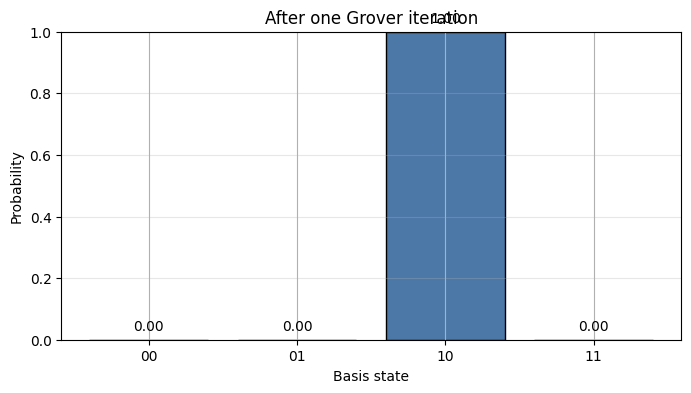

Could not draw the circuit with matplotlib.
Reason: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."
     ┌───┐┌───┐   ┌───┐┌───┐┌───┐   ┌───┐┌───┐
q_0: ┤ H ├┤ X ├─■─┤ X ├┤ H ├┤ X ├─■─┤ X ├┤ H ├
     ├───┤└───┘ │ ├───┤├───┤└───┘ │ ├───┤├───┤
q_1: ┤ H ├──────■─┤ H ├┤ X ├──────■─┤ X ├┤ H ├
     └───┘        └───┘└───┘        └───┘└───┘


In [ ]:
qc = QuantumCircuit(2)
qc.h([0, 1])
apply_phase_oracle(qc, best_bitstring)
apply_diffuser(qc)

state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print(f"Target portfolio: {best_bitstring}")
print("Probabilities after one Grover iteration:", probs)
plot_probabilities(probs, "After one Grover iteration")

# For 4 candidates, one Grover iteration should strongly amplify the marked state.
try:
    display(qc.draw("mpl"))
except Exception as error:
    print("Could not draw the circuit with matplotlib.")
    print("Reason:", error)
    print(qc.draw())


Current target label: 01


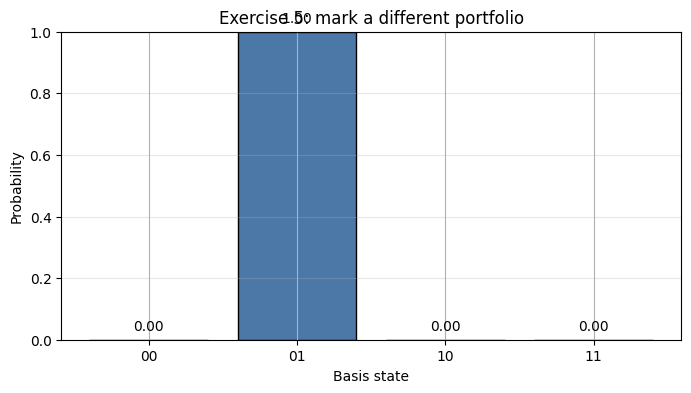

In [ ]:
manual_target = "01"  # change this

qc = QuantumCircuit(2)
qc.h([0, 1])

# // TODO: Apply the oracle to manual_target
apply_phase_oracle(qc, manual_target)

# // TODO: Apply the diffuser
apply_diffuser(qc)

# // TODO: Plot the probabilities
state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print("Current target label:", manual_target)
plot_probabilities(probs, "Exercise 5: mark a different portfolio")

Current target label: 11


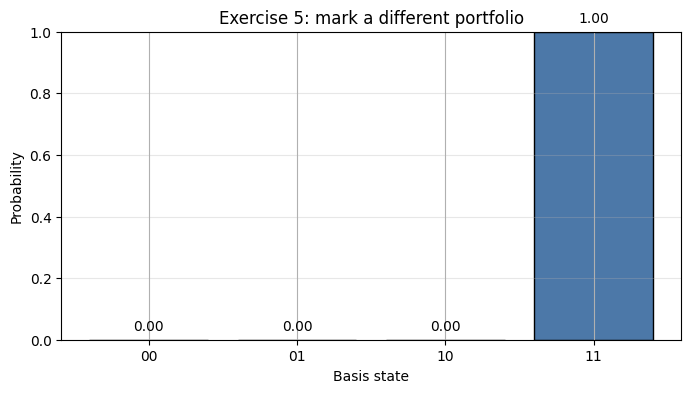

In [ ]:
manual_target = "11"  # and so on~!

qc = QuantumCircuit(2)
qc.h([0, 1])

# // TODO: Apply the oracle to manual_target
apply_phase_oracle(qc, manual_target)

# // TODO: Apply the diffuser
apply_diffuser(qc)

# // TODO: Plot the probabilities
state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

print("Current target label:", manual_target)
plot_probabilities(probs, "Exercise 5: mark a different portfolio")

## 10. Interpretation: What did the quantum circuit do?

The classical part evaluated the portfolios.

The oracle encoded the selected answer.

Grover then amplified the marked candidate.

This notebook does **not** prove quantum advantage.

The goal is to understand basic quantum computing ideas with a simple finance example.

| Classical concept | Quantum concept |
|---|---|
| portfolio candidate | basis state |
| evaluating criterion | oracle definition |
| selecting candidate | measurement |
| amplifying good candidate | Grover iteration |


## 11. Final Mini-Project

Create a new toy quantum portfolio search.

Requirements:
1. Choose 4 candidate portfolios.
2. Compute return, volatility and Sharpe.
3. Choose the best portfolio under one criterion:
   - max Sharpe, or
   - min volatility, or
   - max return with volatility below a threshold.
4. Map the 4 portfolios to `|00>`, `|01>`, `|10>`, `|11>`.
5. Build the equal superposition circuit.
6. Build the oracle for the selected portfolio.
7. Apply the diffuser.
8. Plot probabilities before and after Grover.
9. Write 3 short conclusions in Markdown.

## Checklist
- [ ] I defined 4 portfolios.
- [ ] My weights sum to 1 in every portfolio.
- [ ] I computed return, volatility and Sharpe.
- [ ] I chose a clear selection rule.
- [ ] I mapped the 4 portfolios to 4 basis states.
- [ ] I plotted probabilities before Grover.
- [ ] I plotted probabilities after Grover.
- [ ] I wrote 3 short conclusions.


,bitstring,name,annual_return,annual_volatility,sharpe
0,00,Portfolio A,0.1299,0.1235,0.8901
1,01,Portfolio B,0.1296,0.1331,0.8235
2,10,Portfolio C,0.1487,0.1578,0.8156
3,11,Portfolio D,0.1539,0.1648,0.8124


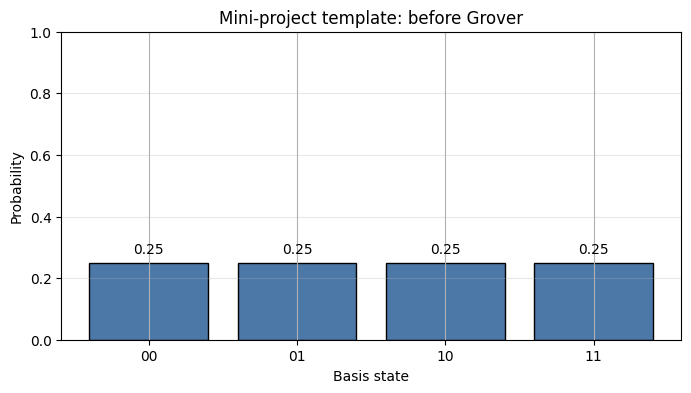

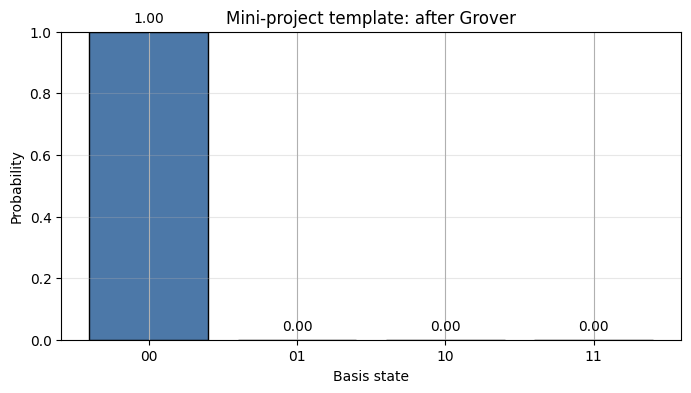

Placeholder target bitstring: 00


In [ ]:
# This template runs with placeholder values.
# Replace the example labels and weights with your own ideas.

student_portfolios = {
    "00": {"name": "Portfolio A", "weights": np.array([0.25, 0.25, 0.25, 0.25])},
    "01": {"name": "Portfolio B", "weights": np.array([0.35, 0.25, 0.25, 0.15])},
    "10": {"name": "Portfolio C", "weights": np.array([0.45, 0.30, 0.15, 0.10])},
    "11": {"name": "Portfolio D", "weights": np.array([0.55, 0.25, 0.10, 0.10])},
}

# // TODO 1: Define your portfolio weights.
# Make sure each weight vector sums to 1.

# // TODO 2: Compute metrics for your 4 portfolios.
student_rows = []
for bitstring, info in student_portfolios.items():
    weights = info["weights"]
    student_rows.append(
        {
            "bitstring": bitstring,
            "name": info["name"],
            "annual_return": portfolio_return(weights, mu),
            "annual_volatility": portfolio_volatility(weights, cov),
            "sharpe": portfolio_sharpe(weights, mu, cov, rf=0.02),
        }
    )

student_metrics_df = pd.DataFrame(student_rows)
display(student_metrics_df.round(4))

# // TODO 3: Choose target bitstring with your own rule -- using min volatility
student_target_bitstring = student_metrics_df.loc[
    student_metrics_df["annual_volatility"].idxmin(), "bitstring"
]
# // TODO 4: Build the equal superposition circuit.
qc_before = QuantumCircuit(2)
qc_before.h([0, 1])
before_probs = Statevector.from_instruction(qc_before).probabilities_dict()

# // TODO 5: Apply oracle.
# // TODO 6: Apply diffuser.
qc_after = QuantumCircuit(2)
qc_after.h([0, 1])
apply_phase_oracle(qc_after, student_target_bitstring)
apply_diffuser(qc_after)

# // TODO 7: Plot probabilities before and after Grover.
before_probs = Statevector.from_instruction(qc_before).probabilities_dict()
after_probs = Statevector.from_instruction(qc_after).probabilities_dict()

plot_probabilities(before_probs, "Mini-project template: before Grover")
plot_probabilities(after_probs, "Mini-project template: after Grover")

print("Placeholder target bitstring:", student_target_bitstring)

###### TODO 8: Write conclusions in Markdown below.

### Conclusions

1. The classical model evaluates all candidate portfolios using return, volatility, and Sharpe ratio, while the quantum circuit does not compute these metrics.

2. The oracle encodes the chosen optimal portfolio by marking its corresponding quantum state through a phase flip.

3. After applying the Grover diffuser, the probability of the marked portfolio increases, demonstrating the idea of amplitude amplification rather than classical computation. (In other words:  the reason Grover works so cleanly here is partly because 4 = 2² is a special case where exactly one iteration achieves near-perfect amplification. With more candidates (say 16 or 64), you'd need more iterations and the amplification would be less clean.)

---



## 12. Common mistakes

- Confusing probabilities with amplitudes.
- Thinking the oracle magically knows the answer.
- Forgetting that this is a toy example.
- Confusing qubit order and bitstring labels.
- Thinking this is investment advice.
- Thinking Grover computes the Sharpe ratio.
